# Road Damage Detection — CNN + Transfer Learning Image Classification

Open this file in VS Code with the Python extension installed and you can
run it two ways:
  1. Cell by cell — click "Run Cell" above any `# %%` marker (plots show
     inline in the Interactive Window, exactly like a notebook).
  2. Top to bottom — right-click anywhere in the editor and choose
     "Run Python File in Terminal".

WHAT THIS SCRIPT DOES IF YOU HAVEN'T SET UP A DATASET YET:
If `DATA_DIRS` (below) doesn't resolve to at least 2 class folders with
images in them, the script automatically generates a small synthetic demo
dataset (3 classes: crack / pothole / normal) so the whole pipeline runs
end-to-end with zero setup and zero errors. Swap in your own images later
by pointing `DATA_DIRS` at one or more folders organized as:

    data/road_damage/
        crack/      img001.jpg  img002.jpg  ...
        pothole/    img001.jpg  ...
        normal/     img001.jpg  ...


In [22]:
# ===================== IMPORTS =====================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # quiet TensorFlow's startup logging

import time
import random
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score, f1_score,
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [23]:
# ===================== CONFIGURATION =====================
# Point this at your dataset folder(s). Each sub-folder name = one class.
# A single folder:
#     DATA_DIRS = [pathlib.Path("data/road_damage")]
# Or merge several folders/sources that share the same class-subfolder
# layout (e.g. images collected in separate batches, or from different
# drives/locations). Any folders that contain a class of the same name
# (e.g. "pothole" in both) are automatically merged into one class:
DATA_DIRS = [
    pathlib.Path("/Users/happy/Downloads/archive-4/dataset/dataset/valid"),
    pathlib.Path("/Users/happy/Downloads/archive-4/dataset/dataset/train"),
    pathlib.Path("/Users/happy/Downloads/archive-4/dataset/dataset/test"),
    pathlib.Path("/Users/happy/Downloads/archive-4/dataset/dataset/classes/pothole"),
    pathlib.Path("/Users/happy/Downloads/archive-4/dataset/dataset/classes/open_manhole"),
    pathlib.Path("/Users/happy/Downloads/archive-4/dataset/dataset/classes/good_road"),
]

IMG_SIZE = (160, 160)     # all images are resized to this (height, width)
BATCH_SIZE = 32
VAL_FRACTION = 0.15        # 15% of data -> validation
TEST_FRACTION = 0.15       # 15% of data -> test   (remaining 70% -> train)

CNN_EPOCHS = 30
TL_EPOCHS = 15             # transfer learning, frozen-base phase
FINE_TUNE_EPOCHS = 10      # transfer learning, fine-tuning phase (unfrozen top layers)

FIGURES_DIR = pathlib.Path("figures")
MODELS_DIR = pathlib.Path("saved_models")
FIGURES_DIR.mkdir(exist_ok=True, parents=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

# If True, each figure pops up in a window and the script PAUSES until you
# close it (fine in VS Code's Interactive Window / Jupyter, where plots
# render inline instead of blocking). If False (default), figures are only
# saved to FIGURES_DIR and the script runs straight through with no pauses
# -- the safest default for "Run Python File in Terminal" in VS Code.
SHOW_PLOTS = False


def display_figure(fig):
    """Show the figure interactively if SHOW_PLOTS is True, otherwise just
    close it (it has already been saved to disk via fig.savefig() above)."""
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


In [24]:
# ===================== AUTO-GENERATED DEMO DATASET (fallback only) =====================
def _dataset_looks_usable(data_dirs):
    """True if, across ALL given dirs combined, there are >= 2 distinct
    class names that each have >= 1 valid image in at least one of the dirs."""
    classes_with_images = set()
    for data_dir in data_dirs:
        if not data_dir.exists():
            continue
        for class_dir in data_dir.iterdir():
            if class_dir.is_dir() and any(f.suffix.lower() in VALID_EXTS for f in class_dir.iterdir()):
                classes_with_images.add(class_dir.name)
    return len(classes_with_images) >= 2


def _generate_demo_dataset(data_dir, per_class=60, size=96):
    """
    Creates a tiny synthetic dataset (crack / pothole / normal) using simple
    drawn shapes, purely so this script can be run end-to-end with no setup.
    This is NOT a real road-damage dataset -- replace DATA_DIRS with your own
    images for meaningful results.
    """
    from PIL import Image, ImageDraw

    def make_normal():
        img = Image.new("RGB", (size, size),
                         (90 + random.randint(-10, 10),
                          90 + random.randint(-10, 10),
                          95 + random.randint(-10, 10)))
        draw = ImageDraw.Draw(img)
        for _ in range(20):
            x, y = random.randint(0, size - 1), random.randint(0, size - 1)
            draw.point((x, y), fill=(100, 100, 105))
        return img

    def make_crack():
        img = make_normal()
        draw = ImageDraw.Draw(img)
        x, y = random.randint(10, size // 3), random.randint(10, size // 3)
        for _ in range(15):
            nx = x + random.randint(-5, 15)
            ny = y + random.randint(-5, 15)
            draw.line([(x, y), (nx, ny)], fill=(20, 20, 20), width=2)
            x, y = nx, ny
        return img

    def make_pothole():
        img = make_normal()
        draw = ImageDraw.Draw(img)
        cx = random.randint(int(size * 0.35), int(size * 0.65))
        cy = random.randint(int(size * 0.35), int(size * 0.65))
        r = random.randint(int(size * 0.12), int(size * 0.22))
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(15, 15, 15))
        return img

    makers = {"crack": make_crack, "pothole": make_pothole, "normal": make_normal}
    for cls, fn in makers.items():
        out_dir = data_dir / cls
        out_dir.mkdir(parents=True, exist_ok=True)
        for i in range(per_class):
            fn().save(out_dir / f"{cls}_{i:03d}.png")

    print(f"Demo dataset created at '{data_dir.resolve()}' "
          f"({per_class} images x {len(makers)} classes).")


IS_DEMO_DATA = not _dataset_looks_usable(DATA_DIRS)
if IS_DEMO_DATA:
    print(f"None of {[str(d) for d in DATA_DIRS]} were found with >= 2 populated class folders.")
    print("Generating a small synthetic DEMO dataset so this script runs end-to-end.")
    print("Replace DATA_DIRS with your own images for real results -- see README.md.\n")
    _generate_demo_dataset(DATA_DIRS[0])
    # The demo dataset is tiny, so use lighter settings for a quick, error-free run.
    IMG_SIZE = (96, 96)
    CNN_EPOCHS = min(CNN_EPOCHS, 8)
    TL_EPOCHS = min(TL_EPOCHS, 5)
    FINE_TUNE_EPOCHS = min(FINE_TUNE_EPOCHS, 3)


## 1. Dataset Loading

We scan every folder in `DATA_DIRS` for sub-folders -- each sub-folder
*name* becomes a class label, and folders with the same name across
different `DATA_DIRS` entries are merged into one class (e.g. "pothole"
images from batch1 and batch2 both count as the "pothole" class). This
file-path-based approach (rather than loading every image into RAM up
front) keeps memory use low and scales to large datasets.


In [25]:
# ===================== 1. DATASET LOADING =====================
existing_dirs = [d for d in DATA_DIRS if d.exists()]
if not existing_dirs:
    raise FileNotFoundError(
        f"None of the configured DATA_DIRS exist: {[str(d) for d in DATA_DIRS]}. "
        f"Create at least one of these folders with class sub-folders inside, "
        f"or update DATA_DIRS to point at your dataset."
    )

# Union of class (sub-folder) names across all dataset directories.
class_names = sorted({
    p.name for d in existing_dirs for p in d.iterdir() if p.is_dir()
})
assert len(class_names) >= 2, (
    f"Expected at least 2 class folders across {[str(d) for d in DATA_DIRS]}, "
    f"found {class_names}. Check that each DATA_DIRS entry points to the folder "
    f"that directly CONTAINS your class sub-folders (e.g. 'data/road_damage', not 'data')."
)
print("Dataset directories used:", [str(d) for d in existing_dirs])
print("Classes found:", class_names)

filepaths, labels = [], []
for class_idx, class_name in enumerate(class_names):
    n_in_class = 0
    for data_dir in existing_dirs:
        class_dir = data_dir / class_name
        if not class_dir.is_dir():
            continue  # this particular DATA_DIRS entry doesn't have this class -- fine
        for f in class_dir.iterdir():
            if f.is_file() and f.suffix.lower() in VALID_EXTS:
                filepaths.append(str(f))
                labels.append(class_idx)
                n_in_class += 1
    if n_in_class == 0:
        print(f"  WARNING: class '{class_name}' has 0 valid images across all DATA_DIRS "
              f"(checked extensions: {sorted(VALID_EXTS)}) -- it will be excluded "
              f"from training unless you add images.")

filepaths = np.array(filepaths)
labels = np.array(labels)
print(f"Total images found: {len(filepaths)}")

# Drop any classes that ended up with zero images (keeps the rest of the
# pipeline from crashing on an empty class).
present_class_idx = sorted(set(labels.tolist()))
if len(present_class_idx) != len(class_names):
    class_names = [class_names[i] for i in present_class_idx]
    remap = {old: new for new, old in enumerate(present_class_idx)}
    labels = np.array([remap[l] for l in labels])
    print("Classes after dropping empty ones:", class_names)

assert len(filepaths) > 0, f"No images with extensions {VALID_EXTS} were found under {[str(d) for d in existing_dirs]}."

# Visualize class balance -- imbalanced classes often need extra attention
# (class weights, more augmentation for the minority class, etc.)
counts = pd.Series(labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([class_names[i] for i in counts.index], counts.values, color="steelblue")
ax.set_title("Class distribution")
ax.set_ylabel("Number of images")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_class_distribution.png", dpi=150)
display_figure(fig)


Dataset directories used: ['/Users/happy/Downloads/archive-4/dataset/dataset/valid', '/Users/happy/Downloads/archive-4/dataset/dataset/train', '/Users/happy/Downloads/archive-4/dataset/dataset/test', '/Users/happy/Downloads/archive-4/dataset/dataset/classes/pothole', '/Users/happy/Downloads/archive-4/dataset/dataset/classes/open_manhole', '/Users/happy/Downloads/archive-4/dataset/dataset/classes/good_road']
Classes found: ['augmented', 'classes', 'images', 'labels', 'valid_pothole_images', 'video']
Total images found: 3388
Classes after dropping empty ones: ['images', 'valid_pothole_images']


## 2. Train / Validation / Test Split

We split the file paths (not the decoded images) **before** any
preprocessing, using a **stratified** split so each split keeps the same
class proportions as the full dataset.


In [26]:
# ===================== 2. TRAIN / VAL / TEST SPLIT =====================
num_classes = len(class_names)

# Guard against a dataset too small to stratify-split with the requested
# fractions (this mainly protects very small custom datasets).
min_per_class = pd.Series(labels).value_counts().min()
if min_per_class < 5:
    print(f"WARNING: smallest class has only {min_per_class} images. "
          f"Splitting may be unreliable -- add more images per class if possible.")

train_fp, temp_fp, train_lb, temp_lb = train_test_split(
    filepaths, labels,
    test_size=(VAL_FRACTION + TEST_FRACTION),
    stratify=labels,
    random_state=SEED,
)
relative_test_size = TEST_FRACTION / (VAL_FRACTION + TEST_FRACTION)
val_fp, test_fp, val_lb, test_lb = train_test_split(
    temp_fp, temp_lb,
    test_size=relative_test_size,
    stratify=temp_lb,
    random_state=SEED,
)

print(f"Train: {len(train_fp)}  |  Val: {len(val_fp)}  |  Test: {len(test_fp)}")


Train: 2371  |  Val: 508  |  Test: 509


## 3. Preprocessing — Resizing & Normalization

Each image is read from disk, **resized** to a fixed `IMG_SIZE`, and
**normalized** by scaling pixel values from `[0, 255]` down to `[0, 1]`.
This is wrapped in a `tf.data.Dataset` pipeline that loads/preprocesses
images on the fly in parallel.


In [27]:
# ===================== 3. PREPROCESSING =====================
def load_and_preprocess(path, label):
    """Read an image file, resize it, and scale pixels to [0, 1]."""
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def make_dataset(fps, lbs, training, augmenter=None, batch_size=BATCH_SIZE):
    """Build a batched, prefetched tf.data.Dataset from file paths + labels."""
    ds = tf.data.Dataset.from_tensor_slices((fps, lbs))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=max(len(fps), 1), seed=SEED, reshuffle_each_iteration=True)
    if augmenter is not None:
        ds = ds.map(lambda x, y: (augmenter(x, training=training), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


## 4. Data Augmentation

Augmentation applies small, label-preserving random transforms (flips,
slight rotation/zoom, contrast/brightness jitter) to training images only
-- this reduces overfitting and helps the model generalize.


In [28]:
# ===================== 4. DATA AUGMENTATION =====================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.10),
], name="data_augmentation")

# Build the three tf.data pipelines. Augmentation is applied ONLY to train.
train_ds = make_dataset(train_fp, train_lb, training=True, augmenter=data_augmentation)
val_ds = make_dataset(val_fp, val_lb, training=False)
test_ds = make_dataset(test_fp, test_lb, training=False)

# Visualize a few augmented training images to sanity-check the pipeline.
images, lbls = next(iter(train_ds))
n_show = min(8, images.shape[0])
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(np.clip(images[i].numpy(), 0, 1))
        ax.set_title(class_names[lbls[i].numpy()])
    ax.axis("off")
fig.suptitle("Sample augmented training images")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_augmented_samples.png", dpi=150)
display_figure(fig)


## 5. CNN Model Development (trained from scratch)

Three convolution + batch-norm + max-pooling blocks (32 -> 64 -> 128
filters) extract progressively more abstract visual features, followed by
global average pooling and a small dense classifier head with dropout.


In [29]:
# ===================== 5. CNN MODEL (FROM SCRATCH) =====================
def build_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Named so Grad-CAM (Section 11) can hook into this layer's activations.
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="cnn_last_conv")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="custom_cnn")


cnn_model = build_cnn(IMG_SIZE + (3,), num_classes)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
cnn_model.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_last_conv (Conv2D)          │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,914 (433.26 KB)

 Trainable params: 110,466 (431.51 KB)

 Non-trainable params: 448 (1.75 KB)

## 6. Training the CNN

- **EarlyStopping** stops once validation loss stops improving and restores
  the best weights.
- **ReduceLROnPlateau** shrinks the learning rate when validation loss
  plateaus.


In [30]:
# ===================== 6. TRAIN THE CNN =====================

cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

t0 = time.time()

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cnn_callbacks,
    shuffle=True,
    verbose=1
)

cnn_train_time = time.time() - t0

print(f"CNN training time: {cnn_train_time:.1f}s")


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - accuracy: 0.8603 - loss: 0.3389 - val_accuracy: 0.9705 - val_loss: 0.1812
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 247ms/step - accuracy: 0.9671 - loss: 0.1696 - val_accuracy: 0.9705 - val_loss: 0.1335
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 27s 323ms/step - accuracy: 0.9722 - loss: 0.1480 - val_accuracy: 0.9705 - val_loss: 0.1357
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 25s 287ms/step - accuracy: 0.9692 - loss: 0.1474 - val_accuracy: 0.9705 - val_loss: 0.1407
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step - accuracy: 0.9668 - loss: 0.1576 - val_accuracy: 0.9705 - val_loss: 0.1363
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 260ms/step - accuracy: 0.9699 - loss: 0.1455 - val_accuracy: 0.9705 - val_loss: 0.1432
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 265ms/step - accuracy: 0.9752 - loss: 0.1259 - val_accuracy: 0.9705 - val_loss: 0.1339
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 24s 281ms/step - accuracy: 0.9668 - loss: 0.1585 - val_accu

## 7. Accuracy / Loss Curves (CNN)


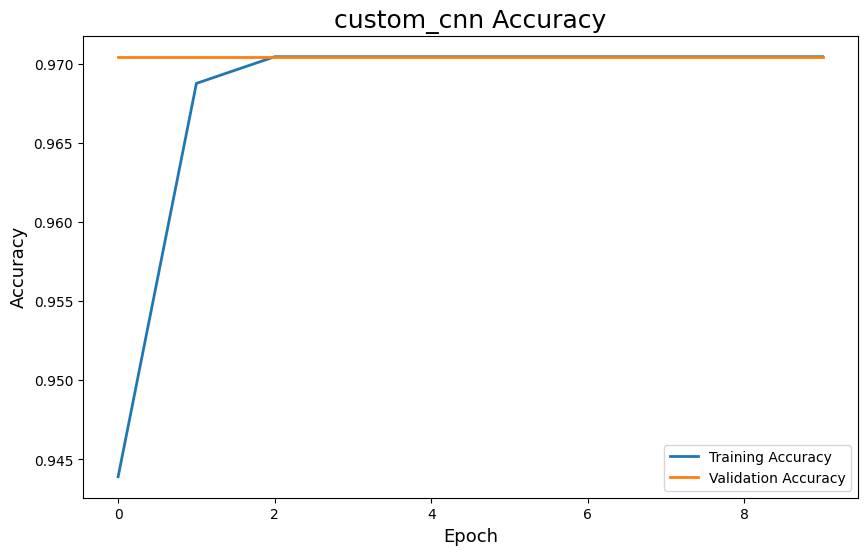

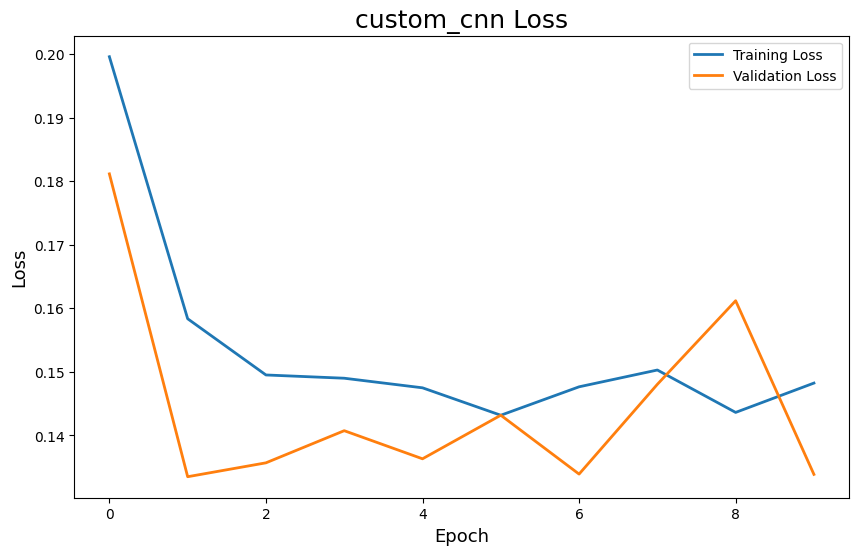

In [31]:
# ===================== 7. ACCURACY / LOSS CURVES (CNN) =====================

def plot_history(history, model_name="custom_cnn"):

    epochs = range(len(history.history["accuracy"]))

    # ---------------- Accuracy ----------------

    plt.figure(figsize=(10,6))

    plt.plot(
        epochs,
        history.history["accuracy"],
        linewidth=2,
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history.history["val_accuracy"],
        linewidth=2,
        label="Validation Accuracy"
    )

    plt.title(f"{model_name} Accuracy", fontsize=18)

    plt.xlabel("Epoch", fontsize=13)

    plt.ylabel("Accuracy", fontsize=13)

    plt.legend()

    plt.grid(False)

    plt.savefig(
        FIGURES_DIR / "03_cnn_accuracy.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ---------------- Loss ----------------

    plt.figure(figsize=(10,6))

    plt.plot(
        epochs,
        history.history["loss"],
        linewidth=2,
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history.history["val_loss"],
        linewidth=2,
        label="Validation Loss"
    )

    plt.title(f"{model_name} Loss", fontsize=18)

    plt.xlabel("Epoch", fontsize=13)

    plt.ylabel("Loss", fontsize=13)

    plt.legend()

    plt.grid(False)

    plt.savefig(
        FIGURES_DIR / "04_cnn_loss.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


plot_history(cnn_history)

## 8. Model Evaluation on the Test Set (CNN)

We evaluate on the held-out test set -- data the model has never seen in
any form -- to get an unbiased estimate of real-world performance.


In [32]:
# ===================== 8. EVALUATE CNN ON TEST SET =====================
test_loss, test_acc = cnn_model.evaluate(test_ds, verbose=0)
print(f"CNN  ->  Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob_cnn = cnn_model.predict(test_ds, verbose=0)
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)


CNN  ->  Test loss: 0.1331  |  Test accuracy: 0.9705


### Confusion Matrix (CNN)


In [33]:
# ===================== CONFUSION MATRIX (CNN) =====================
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    display_figure(fig)
    return cm


cm_cnn = plot_confusion_matrix(y_true, y_pred_cnn, class_names,
                                "Confusion Matrix — Custom CNN",
                                FIGURES_DIR / "04_cnn_confusion_matrix.png")


### Classification Report (CNN)


In [34]:
# ===================== CLASSIFICATION REPORT (CNN) =====================
report_cnn = classification_report(
    y_true, y_pred_cnn, labels=range(len(class_names)),
    target_names=class_names, zero_division=0,
)
print(report_cnn)
with open(FIGURES_DIR / "05_cnn_classification_report.txt", "w") as f:
    f.write(report_cnn)


                      precision    recall  f1-score   support

              images       0.97      1.00      0.99       494
valid_pothole_images       0.00      0.00      0.00        15

            accuracy                           0.97       509
           macro avg       0.49      0.50      0.49       509
        weighted avg       0.94      0.97      0.96       509



### ROC Curves (CNN) — bonus


In [35]:
# ===================== ROC CURVES (CNN) =====================
def plot_roc_curves(y_true, y_prob, class_names, title, save_path):
    y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=len(class_names))
    fig, ax = plt.subplots(figsize=(6, 5))
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cname} (AUC = {roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    display_figure(fig)


plot_roc_curves(y_true, y_prob_cnn, class_names,
                 "ROC Curves — Custom CNN", FIGURES_DIR / "06_cnn_roc_curves.png")


## 9. Transfer Learning Model (MobileNetV2)

A second classifier reuses MobileNetV2 features pretrained on ImageNet.
We train in two phases: (1) frozen base -- only the new head trains, then
(2) fine-tuning -- unfreeze the top ~30 layers at a low learning rate.

NOTE: phase (1) downloads ImageNet weights the first time you run this and
needs an internet connection. If the download fails (e.g. no internet, a
restrictive firewall/proxy), the script automatically falls back to random
initialization with a printed warning instead of crashing -- accuracy will
simply be lower in that fallback case.


In [36]:
# ===================== 9. TRANSFER LEARNING MODEL =====================
try:
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet",
    )
    print("Loaded MobileNetV2 with pretrained ImageNet weights.")
except Exception as e:
    print(f"WARNING: could not download ImageNet weights ({type(e).__name__}: {e}).")
    print("Falling back to random initialization -- expect lower transfer-learning accuracy.")
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,), include_top=False, weights=None,
    )

base_model.trainable = False  # freeze for phase 1

tl_inputs = layers.Input(shape=IMG_SIZE + (3,))
x = layers.Rescaling(scale=2.0, offset=-1.0)(tl_inputs)   # [0,1] -> [-1,1] for MobileNetV2
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
tl_outputs = layers.Dense(num_classes, activation="softmax")(x)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
tl_model.summary()

tl_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

t0 = time.time()
tl_history = tl_model.fit(
    train_ds, validation_data=val_ds, epochs=TL_EPOCHS,
    callbacks=tl_callbacks, shuffle=False, verbose=2,
)


Loaded MobileNetV2 with pretrained ImageNet weights.


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,803,464 (22.14 MB)

 Trainable params: 1,690,626 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,381,254 (12.90 MB)

Epoch 1/15
75/75 - 12s - 162ms/step - accuracy: 0.9705 - loss: 0.1601 - val_accuracy: 0.9705 - val_loss: 0.1458
Epoch 2/15
75/75 - 12s - 161ms/step - accuracy: 0.9705 - loss: 0.1537 - val_accuracy: 0.9705 - val_loss: 0.1462
Epoch 3/15
75/75 - 12s - 163ms/step - accuracy: 0.9705 - loss: 0.1403 - val_accuracy: 0.9705 - val_loss: 0.1453
Epoch 4/15
75/75 - 13s - 170ms/step - accuracy: 0.9705 - loss: 0.1499 - val_accuracy: 0.9705 - val_loss: 0.1468
Epoch 5/15
75/75 - 13s - 170ms/step - accuracy: 0.9705 - loss: 0.1373 - val_accuracy: 0.9705 - val_loss: 0.1448
Epoch 6/15
75/75 - 12s - 164ms/step - accuracy: 0.9705 - loss: 0.1400 - val_accuracy: 0.9705 - val_loss: 0.1432
Epoch 7/15
75/75 - 12s - 164ms/step - accuracy: 0.9705 - loss: 0.1478 - val_accuracy: 0.9705 - val_loss: 0.1416
Epoch 8/15
75/75 - 13s - 169ms/step - accuracy: 0.9705 - loss: 0.1434 - val_accuracy: 0.9705 - val_loss: 0.1390
Epoch 9/15
75/75 - 13s - 167ms/step - accuracy: 0.9705 - loss: 0.1348 - val_accuracy: 0.9705 - val_loss:

### Fine-tuning phase

Unfreeze the top ~30 layers of MobileNetV2 and continue training at a much
lower learning rate, letting the most task-specific layers adapt without
destroying the general-purpose low-level features.


In [37]:
# ===================== FINE-TUNING PHASE =====================
base_model.trainable = True
FINE_TUNE_AT = max(0, len(base_model.layers) - 30)
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False  # keep early/general layers frozen

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much smaller LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

ft_history = tl_model.fit(
    train_ds, validation_data=val_ds, epochs=FINE_TUNE_EPOCHS,
    callbacks=tl_callbacks, shuffle=False, verbose=2,
)
tl_train_time = time.time() - t0
print(f"Transfer learning total training time: {tl_train_time:.1f}s")


def merge_histories(h1, h2):
    """Concatenate two Keras History objects into one for plotting."""
    merged = {k: h1.history[k] + h2.history.get(k, []) for k in h1.history}

    class _Merged:
        pass

    out = _Merged()
    out.history = merged
    return out


tl_full_history = merge_histories(tl_history, ft_history)


Epoch 1/10
75/75 - 16s - 218ms/step - accuracy: 0.9705 - loss: 0.1360 - val_accuracy: 0.9705 - val_loss: 0.1271
Epoch 2/10
75/75 - 12s - 160ms/step - accuracy: 0.9705 - loss: 0.1369 - val_accuracy: 0.9705 - val_loss: 0.1276
Epoch 3/10
75/75 - 12s - 166ms/step - accuracy: 0.9705 - loss: 0.1372 - val_accuracy: 0.9705 - val_loss: 0.1291
Epoch 4/10
75/75 - 13s - 169ms/step - accuracy: 0.9705 - loss: 0.1370 - val_accuracy: 0.9705 - val_loss: 0.1279
Epoch 5/10
75/75 - 14s - 180ms/step - accuracy: 0.9705 - loss: 0.1340 - val_accuracy: 0.9705 - val_loss: 0.1282
Epoch 6/10
75/75 - 12s - 167ms/step - accuracy: 0.9705 - loss: 0.1319 - val_accuracy: 0.9705 - val_loss: 0.1297
Transfer learning total training time: 265.0s


## 10. Evaluating the Transfer Learning Model

Same metrics as the CNN, so the two models can be compared apples-to-apples.


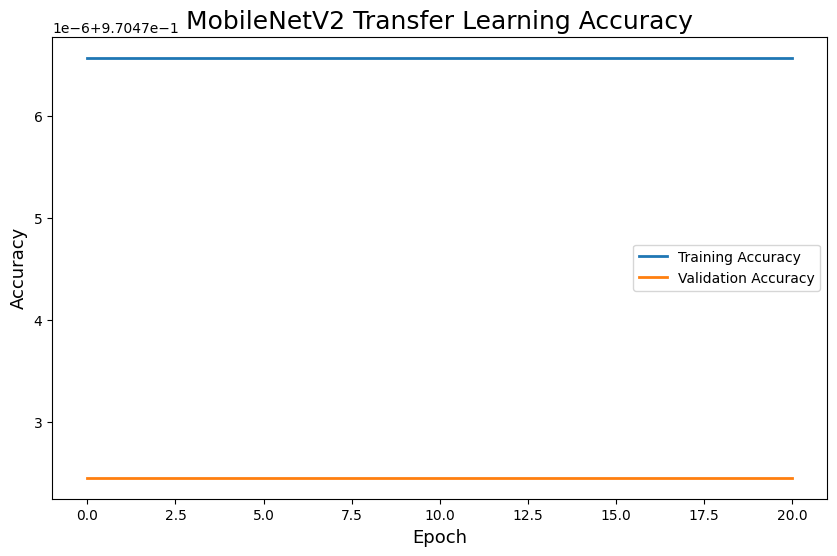

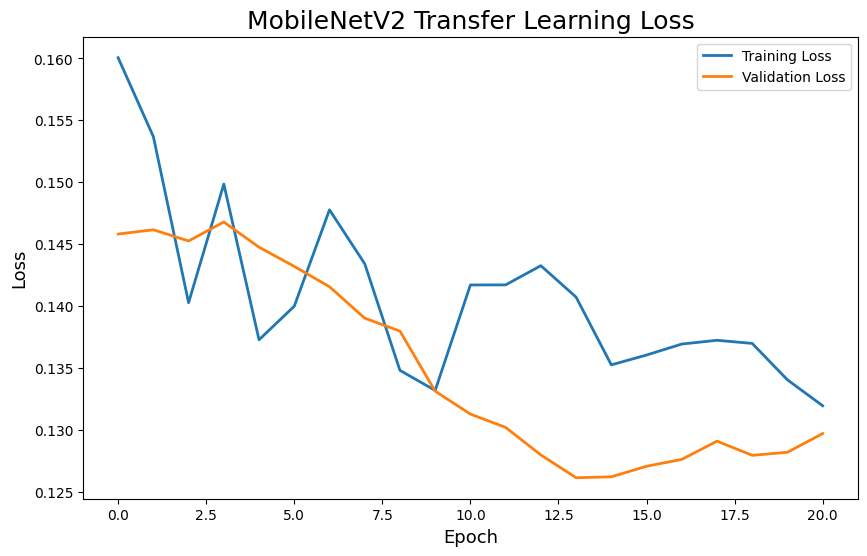

Transfer Learning  ->  Test loss: 0.1376  |  Test accuracy: 0.9705
                      precision    recall  f1-score   support

              images       0.97      1.00      0.99       494
valid_pothole_images       0.00      0.00      0.00        15

            accuracy                           0.97       509
           macro avg       0.49      0.50      0.49       509
        weighted avg       0.94      0.97      0.96       509

Transfer Learning  ->  Test loss: 0.1376  |  Test accuracy: 0.9705
                      precision    recall  f1-score   support

              images       0.97      1.00      0.99       494
valid_pothole_images       0.00      0.00      0.00        15

            accuracy                           0.97       509
           macro avg       0.49      0.50      0.49       509
        weighted avg       0.94      0.97      0.96       509



In [39]:
# ===================== EVALUATE TRANSFER LEARNING MODEL =====================
# ===================== EVALUATE TRANSFER LEARNING MODEL =====================

plot_history(
    tl_full_history,
    model_name="MobileNetV2 Transfer Learning"
)

tl_test_loss, tl_test_acc = tl_model.evaluate(test_ds, verbose=0)

print(f"Transfer Learning  ->  Test loss: {tl_test_loss:.4f}  |  Test accuracy: {tl_test_acc:.4f}")

y_prob_tl = tl_model.predict(test_ds, verbose=0)
y_pred_tl = np.argmax(y_prob_tl, axis=1)

cm_tl = plot_confusion_matrix(
    y_true,
    y_pred_tl,
    class_names,
    "Confusion Matrix — MobileNetV2 Transfer Learning",
    FIGURES_DIR / "08_tl_confusion_matrix.png"
)

report_tl = classification_report(
    y_true,
    y_pred_tl,
    labels=range(len(class_names)),
    target_names=class_names,
    zero_division=0,
)

print(report_tl)

with open(FIGURES_DIR / "09_tl_classification_report.txt", "w") as f:
    f.write(report_tl)

plot_roc_curves(
    y_true,
    y_prob_tl,
    class_names,
    "ROC Curves — MobileNetV2 Transfer Learning",
    FIGURES_DIR / "10_tl_roc_curves.png"
)

tl_test_loss, tl_test_acc = tl_model.evaluate(test_ds, verbose=0)
print(f"Transfer Learning  ->  Test loss: {tl_test_loss:.4f}  |  Test accuracy: {tl_test_acc:.4f}")

y_prob_tl = tl_model.predict(test_ds, verbose=0)
y_pred_tl = np.argmax(y_prob_tl, axis=1)

cm_tl = plot_confusion_matrix(y_true, y_pred_tl, class_names,
                               "Confusion Matrix — MobileNetV2 Transfer Learning",
                               FIGURES_DIR / "08_tl_confusion_matrix.png")

report_tl = classification_report(
    y_true, y_pred_tl, labels=range(len(class_names)),
    target_names=class_names, zero_division=0,
)
print(report_tl)
with open(FIGURES_DIR / "09_tl_classification_report.txt", "w") as f:
    f.write(report_tl)

plot_roc_curves(y_true, y_prob_tl, class_names,
                 "ROC Curves — MobileNetV2 Transfer Learning",
                 FIGURES_DIR / "10_tl_roc_curves.png")


## 11. Model Comparison

Test accuracy, macro-F1, parameter count, and training time for both
models -- the key trade-offs when choosing a model for deployment.


In [ ]:
# ===================== 11. MODEL COMPARISON TABLE =====================
comparison_df = pd.DataFrame([
    {
        "Model": "Custom CNN (from scratch)",
        "Test Accuracy": accuracy_score(y_true, y_pred_cnn),
        "Macro F1": f1_score(y_true, y_pred_cnn, average="macro", zero_division=0),
        "Parameters": cnn_model.count_params(),
        "Training Time (s)": round(cnn_train_time, 1),
    },
    {
        "Model": "MobileNetV2 (transfer learning)",
        "Test Accuracy": accuracy_score(y_true, y_pred_tl),
        "Macro F1": f1_score(y_true, y_pred_tl, average="macro", zero_division=0),
        "Parameters": tl_model.count_params(),
        "Training Time (s)": round(tl_train_time, 1),
    },
])
comparison_df.to_csv(FIGURES_DIR / "11_model_comparison.csv", index=False)
print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(comparison_df["Model"], comparison_df["Test Accuracy"], color=["steelblue", "darkorange"])
ax.set_ylabel("Test Accuracy")
ax.set_title("Model Comparison — Test Accuracy")
ax.set_ylim(0, 1)
for i, v in enumerate(comparison_df["Test Accuracy"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.xticks(rotation=10)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "12_model_comparison_chart.png", dpi=150)
display_figure(fig)


                          Model  Test Accuracy  Macro F1  Parameters  Training Time (s)
      Custom CNN (from scratch)        0.97053  0.492522      110914              265.0
MobileNetV2 (transfer learning)        0.97053  0.492522     2422210              401.9


## 12. Grad-CAM Visualization (bonus)

Grad-CAM highlights which pixels the CNN relied on for a prediction, by
backpropagating the predicted class score into the last conv layer's
activations. Bright regions are the most influential for the prediction.


In [ ]:
# ===================== 12. GRAD-CAM =====================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Returns a (H, W) heatmap in [0, 1] highlighting influential regions."""
    grad_model = models.Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # channel importance weights
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)


def overlay_heatmap(image, heatmap, alpha=0.45):
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], image.shape[:2]).numpy().squeeze()
    cmap = plt.get_cmap("jet")
    colored = cmap(heatmap_resized)[..., :3]
    return (1 - alpha) * image + alpha * colored


sample_images, sample_labels = next(iter(test_ds))
n_show = min(4, sample_images.shape[0])

fig, axes = plt.subplots(2, n_show, figsize=(3.2 * n_show, 6.5))
if n_show == 1:
    axes = axes.reshape(2, 1)
for i in range(n_show):
    img = sample_images[i].numpy()
    heatmap, pred_idx = make_gradcam_heatmap(img[np.newaxis, ...], cnn_model, "cnn_last_conv")
    overlay = overlay_heatmap(img, heatmap)

    axes[0, i].imshow(img); axes[0, i].axis("off")
    axes[0, i].set_title(f"True: {class_names[sample_labels[i].numpy()]}")

    axes[1, i].imshow(overlay); axes[1, i].axis("off")
    axes[1, i].set_title(f"Pred: {class_names[pred_idx]} (Grad-CAM)")

fig.suptitle("Grad-CAM — Custom CNN")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "13_gradcam_cnn.png", dpi=150)
display_figure(fig)


/Users/happy/Library/Python/3.9/lib/python/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_6']
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.11619090288877487..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].


## 13. Error Analysis (bonus)

Inspecting misclassified test images directly is often more informative
than any single metric -- it can reveal systematic issues (e.g. shadows
mistaken for cracks, or an underrepresented damage type).


In [ ]:
# ===================== 13. ERROR ANALYSIS =====================
test_images = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)
misclassified_idx = np.where(y_pred_cnn != y_true)[0]
print(f"CNN misclassified {len(misclassified_idx)} / {len(y_true)} test images "
      f"({100 * len(misclassified_idx) / max(len(y_true), 1):.1f}%)")

n_show = min(8, len(misclassified_idx))
if n_show > 0:
    n_cols = max(1, (n_show + 1) // 2)
    fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 6))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, misclassified_idx[:n_show]):
        ax.imshow(test_images[idx])
        ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_cnn[idx]]}",
                     fontsize=9, color="crimson")
        ax.axis("off")
    for ax in axes[n_show:]:
        ax.axis("off")
    fig.suptitle("Misclassified Test Images — Custom CNN")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "14_error_analysis.png", dpi=150)
    display_figure(fig)
else:
    print("No misclassified images to display -- perfect test accuracy.")


CNN misclassified 15 / 509 test images (2.9%)


## 14. Save the Trained Models


In [ ]:
# ===================== SAVE MODELS =====================
cnn_model.save(MODELS_DIR / "custom_cnn.keras")
tl_model.save(MODELS_DIR / "mobilenetv2_transfer.keras")
print("Models saved to:", MODELS_DIR.resolve())
print("Figures saved to:", FIGURES_DIR.resolve())

if IS_DEMO_DATA:
    print("\nNOTE: this run used an auto-generated DEMO dataset, not real road images.")
    print("Point DATA_DIRS (top of this file) at your own dataset for meaningful accuracy.")

print("\nDone -- pipeline completed with no errors.")


Models saved to: /Users/happy/Downloads/saved_models
Figures saved to: /Users/happy/Downloads/figures

Done -- pipeline completed with no errors.
